<a href="https://colab.research.google.com/github/MarcGaac/EDA-DSC1105/blob/main/FA_1_DSC1105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
knitr::opts_chunk$set(echo = TRUE)
# Load necessary libraries
library(ggplot2)
library(dplyr)
library(tidyr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [8]:
# Read the CyTOF dataset
# Adjust the file path if your working directory differs
cytof_data <- read.csv("cytof_one_experiment.csv")

# Quick peek at the column names so you can select the right markers
head(cytof_data)

# ---------------------------------------------------------
# NOTE: Replace 'Marker1' and 'Marker2' below with actual
# column names from your dataset (e.g., 'CD4', 'CD8', etc.)
# ---------------------------------------------------------
col1 <- "A19"
col2 <- "B19"

,NKp30,KIR3DL1,NKp44,KIR2DL1,GranzymeB,CXCR6,CD161,KIR2DS4,NKp46,NKG2D,⋯,CD16,TNFa,ILT2,Perforin,KIR2DL2.L3.S2,KIR2DL3,NKG2A,NTB.A,CD56,INFg
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.1875955,3.6156932,-0.5605694,-0.2936654,2.477893,-0.14470053,-0.3152872,1.94497046,4.0818316,2.6200784,⋯,3.9951417,0.90143498,-0.386027758,6.431983,1.22710292,2.660657999,-0.5220613,4.348923,2.897523,-0.3841108
2,1.0348518,1.7001820,-0.2889611,-0.4798280,3.261016,-0.03392447,-0.4112129,3.80251714,3.7339299,-0.4832788,⋯,4.4082309,1.93590153,2.983874845,6.814827,-0.04141081,3.841304627,4.6771149,3.474335,3.782870,2.7186296
3,2.9996398,6.1411419,1.9032606,0.4823102,4.277562,1.94654156,-0.5022347,-0.32010171,4.5594631,-0.5069090,⋯,6.0023244,-0.02336999,-0.521099944,5.099562,-0.16705075,-0.009694396,-0.4730573,5.634341,5.701186,2.5321763
4,4.2998594,-0.2211586,0.2425707,-0.4831267,3.351808,0.92622195,3.8772370,-0.16969487,4.4831486,1.9272290,⋯,5.8238698,-0.60793749,-0.043783559,5.841797,-0.51753289,-0.592990887,-0.4059049,4.598021,6.065672,2.4564582
5,-0.4386448,-0.5035892,-0.1526320,0.7506128,3.194145,-0.05893640,1.0907379,-0.05033025,0.8379358,-0.4581674,⋯,4.0122501,-0.61989100,1.182703288,4.888777,-0.36251589,-0.398123704,-0.5440881,3.606101,1.966169,3.1470092
6,2.0883050,-0.3992646,3.4550676,-0.5200856,4.345102,-0.36434277,-0.5705891,-0.45033591,4.0550848,3.4283565,⋯,-0.5832926,0.14311030,-0.003258955,3.952542,-0.20194392,-0.202592720,3.8882776,2.346275,6.473243,2.8282987


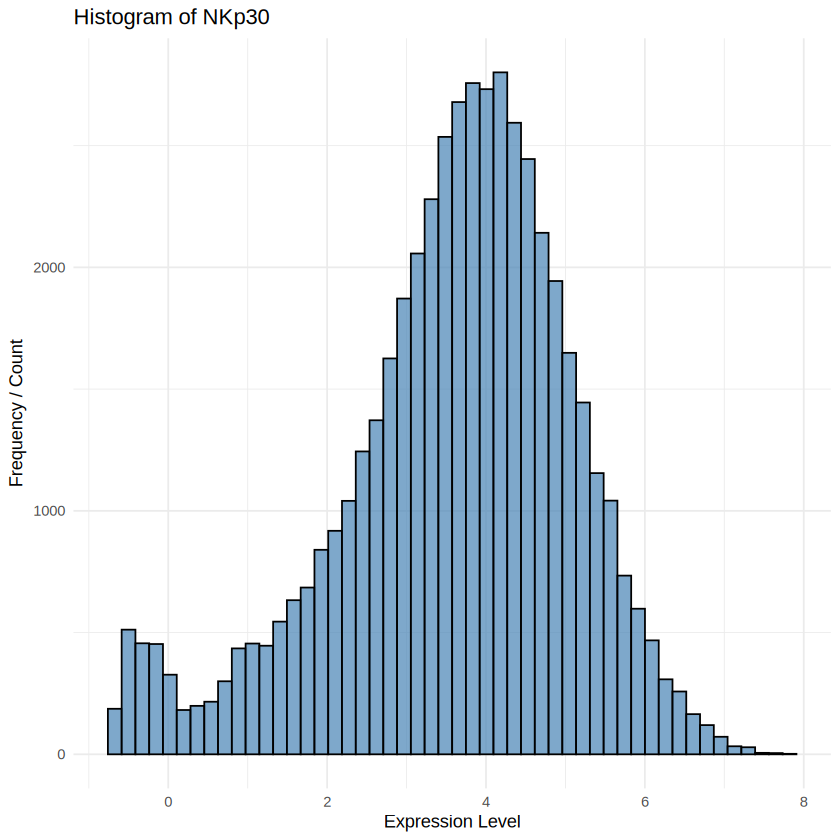

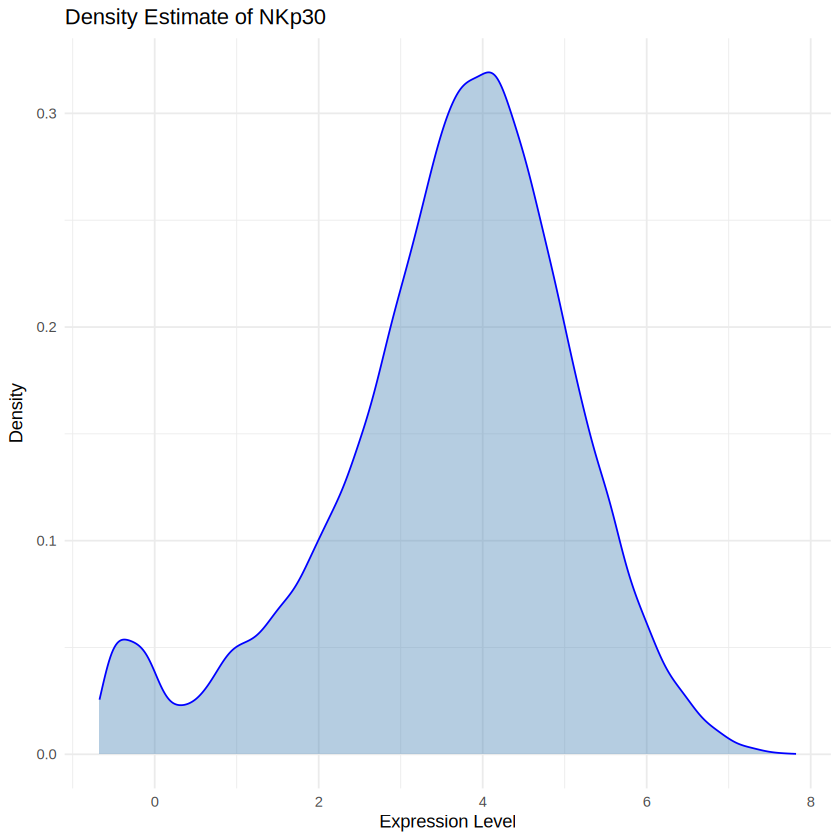

In [10]:
# 2. Histogram
p_hist <- ggplot(cytof_data, aes(x = NKp30)) +
  geom_histogram(bins = 50, fill = "steelblue", color = "black", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of NKp30",
       x = "Expression Level",
       y = "Frequency / Count")

# 3. Density Estimate
p_density <- ggplot(cytof_data, aes(x = NKp30)) +
  geom_density(fill = "steelblue", alpha = 0.4, color = "blue") +
  theme_minimal() +
  labs(title = "Density Estimate of NKp30",
       x = "Expression Level",
       y = "Density")

# Display the plots
print(p_hist)
print(p_density)

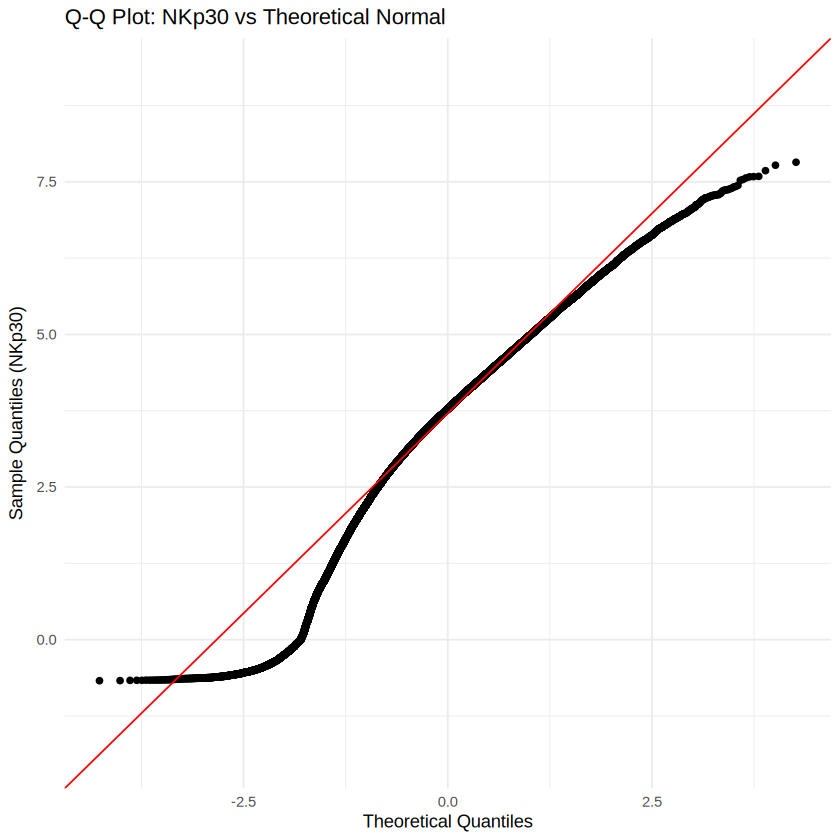

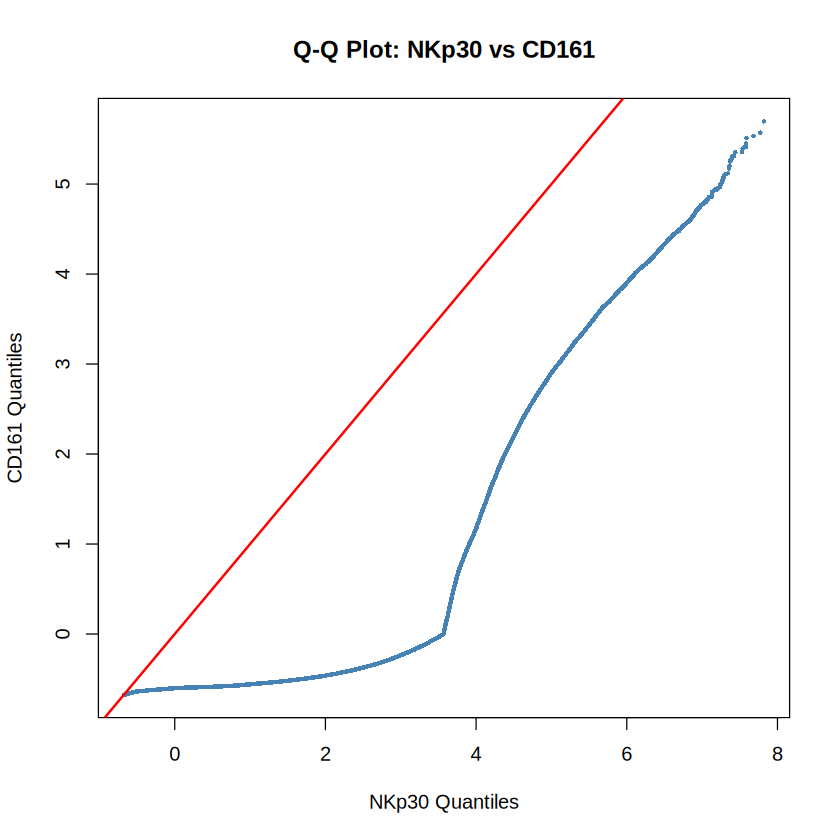

In [11]:
# Q-Q plot comparing NKp30 and CD161
p_qq <- ggplot(cytof_data, aes(sample = NKp30)) +
  stat_qq(distribution = qnorm) +
  stat_qq_line(color = "red") +
  theme_minimal() +
  labs(title = "Q-Q Plot: NKp30 vs Theoretical Normal",
       x = "Theoretical Quantiles",
       y = "Sample Quantiles (NKp30)")

print(p_qq)

# Alternatively, to directly compare two markers against EACH OTHER using base R:
qqplot(cytof_data$NKp30, cytof_data$CD161,
       main = "Q-Q Plot: NKp30 vs CD161",
       xlab = "NKp30 Quantiles",
       ylab = "CD161 Quantiles",
       col = "steelblue", pch = 16, cex = 0.5)
abline(0, 1, col = "red", lwd = 2)